In [1]:
# Sampling the data for training and out-of-time testing

import pandas as pd
import numpy as np

df_raw = pd.read_csv("data/abt_churn.csv")

#defining the df we are using for the model
filtro = df_raw["dtRef"] != '2025-04-01'
filtro_1 = df_raw["dtRef"] == '2025-04-01'

df_train = df_raw[filtro].copy().reset_index(drop=True)
oot = df_raw[filtro_1].copy().reset_index(drop=True) # out of time

X = df_train.drop(columns=["flagChurn", "dtRef", "idUsuario"]).copy()
y = df_train["flagChurn"].copy()


In [2]:
# Train-test split

from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(y_train.mean(), y_test.mean(), oot["flagChurn"].mean())

0.46894559460760715 0.4687199230028874 0.504950495049505


In [3]:
# importing libraries

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score,precision_recall_curve, f1_score, auc, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

In [4]:
#models

preprocessor = StandardScaler()

pipe_log = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_nb = Pipeline([
    ("model", GaussianNB())
])

pipe_dummy = Pipeline([
    ("model", DummyClassifier(strategy="most_frequent"))
])

# Parameters grids

param_grid_log = {
    "model__C": [0.09, 0.1, 0.11],
    "model__penalty": ["l2"]  # scikit-learn logistic regression defaults
}

param_grid_rf = {
    "model__n_estimators": [150, 200, 250],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

param_grid_nb = {
    # GaussianNB has only one major hyperparam (var_smoothing)
    "model__var_smoothing": [1e-5, 1e-4, 1e-3]
}

# Grid Search with Cross-Validation for ROC-AUC

grids = {
    "Logistic Regression": GridSearchCV(pipe_log, param_grid_log, cv=5, scoring="roc_auc", n_jobs=-1),
    "Random Forest": GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring="roc_auc", n_jobs=-1),
    "Naive Bayes": GridSearchCV(pipe_nb, param_grid_nb, cv=5, scoring="roc_auc", n_jobs=-1),
    "Dummy Classifier": GridSearchCV(pipe_dummy, {}, cv=5, scoring="roc_auc", n_jobs=-1)
}

results = {}
pr_curve = {}


for name, grid in grids.items():
    print(f"\n===== {name} =====")
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    y_prob = grid.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    print("Best Params:", grid.best_params_)
    print(classification_report(y_test, y_pred, digits=3))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("AP:", average_precision_score(y_test, y_prob))
    print("Baseline (prevalence):", y_test.mean())

    pr_curve[name] = {
        "precisions": precisions,
        "recalls": recalls,
        "thresholds": thresholds,
        "AP": average_precision_score(y_test, y_prob),
        "y_prob": y_prob
    }
    
    results[name] = {
        "best_params": grid.best_params_,
        "roc_auc": roc_auc_score(y_test, y_prob)
    }


===== Logistic Regression =====
Best Params: {'model__C': 0.11, 'model__penalty': 'l2'}
              precision    recall  f1-score   support

           0      0.808     0.694     0.747       552
           1      0.701     0.813     0.753       487

    accuracy                          0.750      1039
   macro avg      0.754     0.753     0.750      1039
weighted avg      0.758     0.750     0.750      1039

ROC-AUC: 0.8289326845817337
AP: 0.7631719030037645
Baseline (prevalence): 0.4687199230028874

===== Random Forest =====
Best Params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
              precision    recall  f1-score   support

           0      0.795     0.716     0.753       552
           1      0.710     0.791     0.748       487

    accuracy                          0.751      1039
   macro avg      0.753     0.753     0.751      1039
weighted avg      0.755     0.751     0.751      1039

ROC-AUC: 0.822765080498765
AP: 0.7559985

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
# This cell allows to evaluate fully one model at a time

analyse_model = "Logistic Regression"
# analyse_model = "Random Forest"
# analyse_model = "Naive Bayes"

precisions = pr_curve[analyse_model]["precisions"]
recalls = pr_curve[analyse_model]["recalls"]
thresholds = pr_curve[analyse_model]["thresholds"]
ap = pr_curve[analyse_model]["AP"]
y_prob = pr_curve[analyse_model]["y_prob"]

f1_scores = 2 * (precisions * recalls / (precisions + recalls + 1e-9))

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print("Best threshold for max F1:", best_thresh)
print("Precision:", precisions[best_idx], "Recall:", recalls[best_idx])

print("\nPositive prevalence (test):", y_test.mean())
print("Average Precision (AP):", round(ap, 4))

pr_auc = auc(recalls, precisions)   # a different integration; often similar to AP but not identical
print("\nPR-AUC (auc(recalls,precisions)):", round(pr_auc,4))

# Building the selection rate curve

threshold_selection_rates = np.linspace(0, 1, num=thresholds.shape[0]) # for generating a array of threshold same size as thresholds array
selection_rate = []

for t in threshold_selection_rates:
    y_pred = (y_prob >= t).astype(int)
    selection_rate.append(np.mean(y_pred))

Best threshold for max F1: 0.4206513035355535
Precision: 0.6738131699846861 Recall: 0.9034907597535934

Positive prevalence (test): 0.4687199230028874
Average Precision (AP): 0.7632

PR-AUC (auc(recalls,precisions)): 0.762


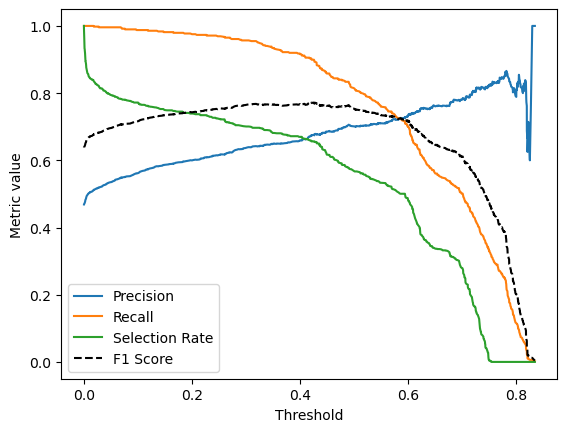

In [48]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, selection_rate, label="Selection Rate")
plt.plot(thresholds, f1_scores[:-1], label="F1 Score", linestyle='--', color='black')
plt.xlabel("Threshold")
plt.ylabel("Metric value")

# plt.plot(recalls[:-1], precisions[:-1], label="PR Curve")
# plt.xlabel("Recall")
# plt.ylabel("Precision")

plt.legend()
plt.show()

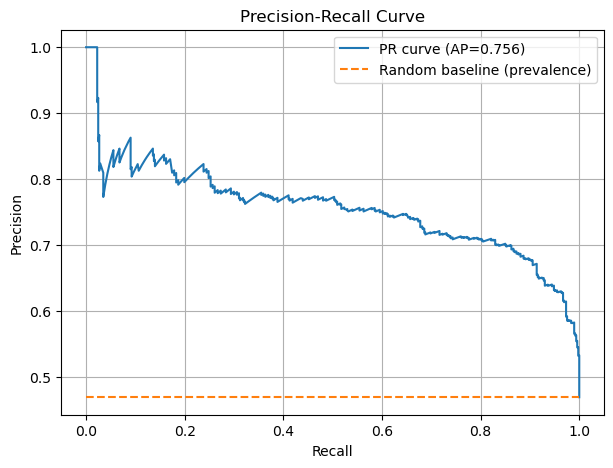

In [48]:
plt.figure(figsize=(7,5))
plt.plot(recalls, precisions, label=f"PR curve (AP={ap:.3f})")
plt.plot([0,1],[y_test.mean(), y_test.mean()], linestyle='--', label='Random baseline (prevalence)')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()